# Day 1 — Exploratory Data Analysis

**Goals:**
1. Validate mining pipeline output
2. Understand class distribution (bug ratio)
3. Identify key features visually
4. Spot data quality issues before modeling

**Run order:** Execute cells top to bottom. Cell 8 needs `git_miner.py` to have run first — skip it if mining is still running.

In [2]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix.csv")
print(df["is_buggy"].value_counts())
print(df[df["is_buggy"] == 1]["file_path"].tolist())

is_buggy
0    164
1     52
Name: count, dtype: int64
['flask/app.py', 'flask/app.py', 'flask/blueprints.py', 'flask/cli.py', 'flask/cli.py', 'flask/cli.py', 'flask/helpers.py', 'flask/helpers.py', 'flask/testing.py', 'flask/wrappers.py', 'src/flask/__init__.py', 'src/flask/app.py', 'src/flask/app.py', 'src/flask/app.py', 'src/flask/app.py', 'src/flask/app.py', 'src/flask/app.py', 'src/flask/app.py', 'src/flask/app.py', 'src/flask/blueprints.py', 'src/flask/blueprints.py', 'src/flask/cli.py', 'src/flask/cli.py', 'src/flask/cli.py', 'src/flask/cli.py', 'src/flask/cli.py', 'src/flask/cli.py', 'src/flask/cli.py', 'src/flask/ctx.py', 'src/flask/ctx.py', 'src/flask/globals.py', 'src/flask/helpers.py', 'src/flask/helpers.py', 'src/flask/helpers.py', 'src/flask/helpers.py', 'src/flask/helpers.py', 'src/flask/json/__init__.py', 'src/flask/json/__init__.py', 'src/flask/logging.py', 'src/flask/sansio/app.py', 'src/flask/scaffold.py', 'src/flask/scaffold.py', 'src/flask/scaffold.py', 'src/flask/sc

In [4]:
import pandas as pd

df_features = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix.csv")
flask_df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\raw\\flask_commits.csv")

feature_paths = set(df_features["file_path"].astype(str))
flask_paths = set(flask_df["file_path"].astype(str))

overlap = feature_paths & flask_paths

print(f"feature_matrix paths : {len(feature_paths)}")
print(f"flask_commits paths  : {len(flask_paths)}")
print(f"Overlap              : {len(overlap)}")
print()
print("Sample feature_matrix paths:")
print(list(feature_paths)[:5])
print()
print("Sample flask_commits paths:")
print(list(flask_paths)[:5])

feature_matrix paths : 52
flask_commits paths  : 77
Overlap              : 52

Sample feature_matrix paths:
['src/flask/cli.py', 'tests/typing/typing_route.py', 'examples/javascript/js_example/views.py', 'src/flask/testing.py', 'src/flask/json/provider.py']

Sample flask_commits paths:
['tests/typing/typing_route.py', 'src/flask/logging.py', 'examples/celery/src/task_app/tasks.py', 'src/flask/sansio/scaffold.py', 'tests/test_apps/helloworld/wsgi.py']


In [2]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix.csv")

old = dict(zip(df["file_path"].astype(str), df["is_buggy"].astype(int)))
new = df.groupby("file_path")["is_buggy"].max().astype(int).to_dict()

print(f"Old buggy count: {sum(old.values())}")   # expect 2
print(f"New buggy count: {sum(new.values())}")   # expect 30-52

Old buggy count: 2
New buggy count: 22


In [4]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix.csv")
print(df["window_end"].describe())
print()
print(df["window_end"].value_counts().sort_index().tail(10))
print()
# See what's in the 5-row test set
df["window_end"] = pd.to_datetime(df["window_end"])
cutoff = df["window_end"].max() - pd.DateOffset(months=3)
test = df[df["window_end"] > cutoff]
print(f"Test set: {len(test)} rows")
print(test["is_buggy"].value_counts())

count                     216
unique                     29
top       2019-08-08 02:05:54
freq                       35
Name: window_end, dtype: object

window_end
2023-07-18 02:05:54    17
2023-10-16 02:05:54     4
2024-01-14 02:05:54    14
2024-04-13 02:05:54     2
2024-07-12 02:05:54     3
2024-10-10 02:05:54     1
2025-01-08 02:05:54     5
2025-07-07 02:05:54     3
2025-10-05 02:05:54     6
2026-04-03 02:05:54     5
Name: count, dtype: int64

Test set: 5 rows
is_buggy
0    5
Name: count, dtype: int64


In [6]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix.csv")
df["window_end"] = pd.to_datetime(df["window_end"])

for months in [3, 6, 12, 18, 24, 36, 48]:
    cutoff = df["window_end"].max() - pd.DateOffset(months=months)
    test = df[df["window_end"] > cutoff]
    train = df[df["window_end"] <= cutoff]
    buggy_in_test = test["is_buggy"].sum()
    print(f"test_months={months:>2}: train={len(train):>3}  test={len(test):>3}  buggy_in_test={buggy_in_test}")
    

test_months= 3: train=211  test=  5  buggy_in_test=0
test_months= 6: train=205  test= 11  buggy_in_test=0
test_months=12: train=202  test= 14  buggy_in_test=1
test_months=18: train=196  test= 20  buggy_in_test=3
test_months=24: train=191  test= 25  buggy_in_test=5
test_months=36: train=149  test= 67  buggy_in_test=13
test_months=48: train=116  test=100  buggy_in_test=23


In [2]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_with_repo.csv")
        
# Check sqlalchemy specifically
sql = df[df["repo_name"] == "sqlalchemy"]
print(sql[["file_path", "is_buggy"]].head(20))
print()

# Check what commit messages triggered the labeling
# Look at your raw commits CSV if you have one

                                        file_path  is_buggy
2170             lib/sqlalchemy/orm/attributes.py         1
2171                lib/sqlalchemy/orm/loading.py         1
2172                  lib/sqlalchemy/orm/state.py         1
2173             lib/sqlalchemy/orm/strategies.py         1
2174        lib/sqlalchemy/orm/instrumentation.py         1
2175             lib/sqlalchemy/orm/interfaces.py         1
2176   lib/sqlalchemy/dialects/oracle/__init__.py         1
2177       lib/sqlalchemy/ext/associationproxy.py         1
2178                         test/requirements.py         1
2179       lib/sqlalchemy/testing/requirements.py         1
2180       lib/sqlalchemy/orm/strategy_options.py         1
2181                   lib/sqlalchemy/sql/crud.py         1
2182  lib/sqlalchemy/dialects/oracle/cx_oracle.py         1
2183        lib/sqlalchemy/dialects/mssql/base.py         1
2184          lib/sqlalchemy/orm/path_registry.py         1
2185            lib/sqlalchemy/orm/persi

In [6]:
import pandas as pd

# Load your raw commits data for sqlalchemy
# adjust path to wherever your raw commit CSV is
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\raw\\sqlalchemy_commits.csv")  

# or check what raw data you have
import os
for f in os.listdir("data/raw"):
    print(f)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/raw'

In [ ]:
import pandas as pd
df = pd.read_csv("data/processed/feature_matrix_clean.csv")
print(f"Total rows     : {len(df)}")
print(f"Unique files   : {df['file_path'].nunique()}")
print(f"Rows per file  : {len(df) / df['file_path'].nunique():.1f} avg")
print()
# Check how many windows per file
print(df.groupby("file_path").size().describe())

In [1]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_clean.csv")
print(f"Total rows     : {len(df)}")
print(f"Unique files   : {df['file_path'].nunique()}")
print(f"Rows per file  : {len(df) / df['file_path'].nunique():.1f} avg")
print()
# Check how many windows per file
print(df.groupby("file_path").size().describe())

Total rows     : 46610
Unique files   : 3867
Rows per file  : 12.1 avg

count    3867.000000
mean       12.053271
std        15.161069
min         1.000000
25%         4.000000
50%         6.000000
75%        15.000000
max       404.000000
dtype: float64


In [7]:
import pandas as pd

df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_with_repo.csv")

print(f"Before: {len(df)} rows, {df['file_path'].nunique()} unique files")

# Identify feature columns
meta_cols = {"repo_name", "file_path", "is_buggy"}
feature_cols = [c for c in df.columns if c not in meta_cols]

# Collapse: last window's features, buggy if ANY window was buggy
df_collapsed = (
    df.groupby(["repo_name", "file_path"])
    .agg(
        {**{c: "last" for c in feature_cols},
         "is_buggy": "max"}
    )
    .reset_index()
)

print(f"After : {len(df_collapsed)} rows, {df_collapsed['file_path'].nunique()} unique files")
print(f"Buggy : {df_collapsed['is_buggy'].sum()} ({df_collapsed['is_buggy'].mean()*100:.1f}%)")
print()
print("Per-repo breakdown after collapse:")
print(
    df_collapsed.groupby("repo_name")["is_buggy"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "buggy", "count": "files", "mean": "rate"})
    .assign(rate=lambda x: (x["rate"]*100).round(1).astype(str) + "%")
)

df_collapsed.to_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_collapsed.csv", index=False)
print()
print("Saved → d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_collapsed.csv")

Before: 46610 rows, 3867 unique files
After : 3894 rows, 3867 unique files
Buggy : 1675 (43.0%)

Per-repo breakdown after collapse:
            buggy  files   rate
repo_name                      
aiohttp        57    115  49.6%
celery        125    254  49.2%
click          37     71  52.1%
django        601   1778  33.8%
falcon         90    170  52.9%
flask          33     77  42.9%
pymongo       123    252  48.8%
redis-py       80    192  41.7%
requests       13     42  31.0%
sqlalchemy    370    630  58.7%
tornado        38     91  41.8%
werkzeug      108    222  48.6%

Saved → d:\Data Science\projects\defect-predictor\data\processed\feature_matrix_collapsed.csv


In [8]:
import pandas as pd

df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_with_repo.csv")

meta_cols = {"repo_name", "file_path", "is_buggy"}
drop_in_features = {"window_start", "commits_in_window"}  # drop these
keep_as_date = "window_end"  # keep this as commit_date

feature_cols = [
    c for c in df.columns 
    if c not in meta_cols 
    and c not in drop_in_features
    and c != keep_as_date
]

df_collapsed = (
    df.sort_values("window_end")
    .groupby(["repo_name", "file_path"])
    .agg(
        {**{c: "last" for c in feature_cols},
         "window_end": "last",   # latest window date
         "is_buggy": "max"}
    )
    .reset_index()
    .rename(columns={"window_end": "commit_date"})
)

print(f"Shape    : {df_collapsed.shape}")
print(f"Buggy    : {df_collapsed['is_buggy'].sum()} ({df_collapsed['is_buggy'].mean()*100:.1f}%)")
print(f"Date range: {df_collapsed['commit_date'].min()} → {df_collapsed['commit_date'].max()}")

df_collapsed.to_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_collapsed.csv", index=False)
print("Saved → feature_matrix_collapsed.csv")

KeyError: 'window_end'

In [9]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_with_repo.csv")
print(df.columns.tolist())
print()
# Look for any date-like columns
date_cols = [c for c in df.columns if any(x in c.lower() for x in ["date", "time", "window", "start", "end", "seen"])]
print("Date-like columns:", date_cols)
print()
print(df.shape)

['repo_name', 'file_path', 'is_buggy', 'code_churn_30d', 'code_churn_90d', 'commit_count_30d', 'commit_count_90d', 'author_count_90d', 'fix_density', 'days_since_last_change', 'commit_burst_30d', 'ownership_score', 'ast_cyclomatic_complexity', 'ast_cognitive_complexity', 'max_nesting_depth', 'num_functions', 'num_classes', 'avg_function_length', 'max_args_per_function', 'num_imports', 'ast_node_count', 'has_try_except']

Date-like columns: []

(46610, 22)


In [10]:
import pandas as pd

# Try each of these until one works
for path in [
    "d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_clean.csv",
    "d:\\Data Science\\projects\\defect-predictor\\data\\processed\\combined_features.csv", 
    "d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_imputed.csv",
]:
    try:
        df = pd.read_csv(path, nrows=2)
        date_cols = [c for c in df.columns if any(x in c.lower() 
                     for x in ["date","time","window","start","end","seen"])]
        print(f"{path}")
        print(f"  columns: {df.columns.tolist()}")
        print(f"  date-like: {date_cols}")
        print()
    except FileNotFoundError:
        print(f"  NOT FOUND: {path}")

d:\Data Science\projects\defect-predictor\data\processed\feature_matrix_clean.csv
  columns: ['file_path', 'is_buggy', 'code_churn_30d', 'code_churn_90d', 'commit_count_30d', 'commit_count_90d', 'author_count_90d', 'fix_density', 'days_since_last_change', 'commit_burst_30d', 'ownership_score', 'ast_cyclomatic_complexity', 'ast_cognitive_complexity', 'max_nesting_depth', 'num_functions', 'num_classes', 'avg_function_length', 'max_args_per_function', 'num_imports', 'ast_node_count', 'has_try_except']
  date-like: []

  NOT FOUND: d:\Data Science\projects\defect-predictor\data\processed\combined_features.csv
d:\Data Science\projects\defect-predictor\data\processed\feature_matrix_imputed.csv
  columns: ['file_path', 'is_buggy', 'total_commits', 'bug_fix_commits', 'first_seen', 'last_seen', 'window_end', 'code_churn_30d', 'code_churn_90d', 'commit_count_30d', 'commit_count_90d', 'author_count_90d', 'bug_fix_count_90d', 'fix_density', 'days_since_last_change', 'commit_burst_30d', 'ownership_

In [12]:
import pandas as pd

df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_with_repo.csv")
print(f"Shape: {df.shape}")
print(f"Repos: {df['repo_name'].nunique() if 'repo_name' in df.columns else 'NO REPO COL'}")
if "window_end" in df.columns:
    print(f"window_end range: {df['window_end'].min()} → {df['window_end'].max()}")
elif "commit_date" in df.columns:
    print(f"commit_date range: {df['commit_date'].min()} → {df['commit_date'].max()}")
else:
    print(f"No window_end/commit_date column found. Date-like columns: {date_cols}")
print(f"Buggy: {df['is_buggy'].sum()} ({df['is_buggy'].mean()*100:.1f}%)")

Shape: (46610, 22)
Repos: 12
No window_end/commit_date column found. Date-like columns: ['first_seen', 'last_seen', 'window_end']
Buggy: 14959 (32.1%)


In [ ]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_with_repo.csv")
print("window_end sample:", df["window_end"].head(3).tolist())
    

In [15]:
import pandas as pd

df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_with_repo.csv")

# Confirm window_end is there
print(df.columns.tolist())
print("dtype:", df["window_end"].dtype)

['repo_name', 'file_path', 'is_buggy', 'code_churn_30d', 'code_churn_90d', 'commit_count_30d', 'commit_count_90d', 'author_count_90d', 'fix_density', 'days_since_last_change', 'commit_burst_30d', 'ownership_score', 'ast_cyclomatic_complexity', 'ast_cognitive_complexity', 'max_nesting_depth', 'num_functions', 'num_classes', 'avg_function_length', 'max_args_per_function', 'num_imports', 'ast_node_count', 'has_try_except']


KeyError: 'window_end'

In [2]:
import pandas as pd
import numpy as np

# Load imputed (has window_end) + with_repo (has repo_name, correct labels)
imputed = pd.read_csv(
    "d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_imputed.csv"
)
with_repo = pd.read_csv(
    "d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_with_repo.csv"
)

# with_repo has the correct tightened labels — use those, not imputed's
# Join: take window_end from imputed, everything else from with_repo
date_lookup = (
    imputed[["file_path", "window_end"]]
    .dropna(subset=["window_end"])
    .drop_duplicates("file_path")
)

df = with_repo.merge(date_lookup, on="file_path", how="left")
print(f"Joined shape       : {df.shape}")
print(f"window_end nulls   : {df['window_end'].isna().sum()}")
print(f"Buggy              : {df['is_buggy'].sum()} ({df['is_buggy'].mean()*100:.1f}%)")

# For files with no window_end, assign a plausible date from days_since_last_change
# Use a reference date of today minus days_since_last_change
ref_date = pd.Timestamp("2026-05-28")
mask_null = df["window_end"].isna()
df.loc[mask_null, "window_end"] = (
    ref_date - pd.to_timedelta(df.loc[mask_null, "days_since_last_change"], unit="D")
).dt.strftime("%Y-%m-%d %H:%M:%S")

print(f"window_end nulls after fill: {df['window_end'].isna().sum()}")

# Drop leaky/meta cols
drop_cols = {"commits_in_window"}
meta_cols = {"repo_name", "file_path", "is_buggy", "window_end"}
feature_cols = [
    c for c in df.columns
    if c not in meta_cols and c not in drop_cols
]
print(f"Feature cols ({len(feature_cols)}): {feature_cols}")

# Collapse
df_collapsed = (
    df.sort_values("window_end")
    .groupby(["repo_name", "file_path"])
    .agg(
        {**{c: "last" for c in feature_cols},
         "window_end": "last",
         "is_buggy":   "max"}
    )
    .reset_index()
    .rename(columns={"window_end": "commit_date"})
)

print(f"\nCollapsed shape : {df_collapsed.shape}")
print(f"Buggy           : {df_collapsed['is_buggy'].sum()} ({df_collapsed['is_buggy'].mean()*100:.1f}%)")
print(f"Date sample     : {df_collapsed['commit_date'].dropna().head(3).tolist()}")
print()
print(
    df_collapsed.groupby("repo_name")["is_buggy"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "buggy", "count": "files", "mean": "rate"})
    .assign(rate=lambda x: (x["rate"]*100).round(1).astype(str) + "%")
    .sort_values("files", ascending=False)
)

df_collapsed.to_csv(
    "d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_collapsed.csv",
    index=False
)
print("\nSaved → feature_matrix_collapsed.csv")

Joined shape       : (46610, 23)
window_end nulls   : 3904
Buggy              : 14959 (32.1%)
window_end nulls after fill: 0
Feature cols (19): ['code_churn_30d', 'code_churn_90d', 'commit_count_30d', 'commit_count_90d', 'author_count_90d', 'fix_density', 'days_since_last_change', 'commit_burst_30d', 'ownership_score', 'ast_cyclomatic_complexity', 'ast_cognitive_complexity', 'max_nesting_depth', 'num_functions', 'num_classes', 'avg_function_length', 'max_args_per_function', 'num_imports', 'ast_node_count', 'has_try_except']

Collapsed shape : (3894, 23)
Buggy           : 1675 (43.0%)
Date sample     : ['2026-05-18 21:36:58', '2026-05-13 19:00:42', '2026-04-29 00:00:00']

            buggy  files   rate
repo_name                      
django        601   1778  33.8%
sqlalchemy    370    630  58.7%
celery        125    254  49.2%
pymongo       123    252  48.8%
werkzeug      108    222  48.6%
redis-py       80    192  41.7%
falcon         90    170  52.9%
aiohttp        57    115  49.6%


In [4]:
import pandas as pd

df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_collapsed.csv")

# Files from imputed (real dates) vs synthetic dates
# Real dates are before 2026; synthetic ones cluster in 2026
df["commit_date"] = pd.to_datetime(df["commit_date"])
real_dates = df[df["commit_date"] < "2026-01-01"]
synthetic = df[df["commit_date"] >= "2026-01-01"]

print(f"Real dates  : {len(real_dates)} files  buggy={real_dates['is_buggy'].mean()*100:.1f}%")
print(f"Synthetic   : {len(synthetic)} files  buggy={synthetic['is_buggy'].mean()*100:.1f}%")
print()

# Check temporal split on real dates only
for months in [12, 18, 24, 36]:
    cutoff = real_dates["commit_date"].max() - pd.DateOffset(months=months)
    test = real_dates[real_dates["commit_date"] > cutoff]
    train = real_dates[real_dates["commit_date"] <= cutoff]
    print(f"test_months={months}: train={len(train)}  test={len(test)}  buggy_in_test={test['is_buggy'].sum()}")

Real dates  : 1623 files  buggy=55.9%
Synthetic   : 2271 files  buggy=33.8%

test_months=12: train=990  test=633  buggy_in_test=420
test_months=18: train=878  test=745  buggy_in_test=487
test_months=24: train=752  test=871  buggy_in_test=566
test_months=36: train=528  test=1095  buggy_in_test=668


In [6]:
import pandas as pd

df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_collapsed.csv")
df["commit_date"] = pd.to_datetime(df["commit_date"])
real = df[df["commit_date"] < "2026-01-01"].copy()
real.to_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_final.csv", index=False)
print(f"Saved: {len(real)} files, {real['is_buggy'].sum()} buggy ({real['is_buggy'].mean()*100:.1f}%)")

Saved: 1623 files, 908 buggy (55.9%)


In [ ]:
import pandas as pd
import numpy as np
import pickle
import sys
sys.path.insert(0, "d:\\Data Science\\projects\\defect-predictor")

from src.models.train import DefectXGBoost
from src.models.evaluate import TemporalEvaluator

df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_final.csv")
evaluator = TemporalEvaluator()
df_train, df_test = evaluator.temporal_train_test_split(df, test_months=12)

drop_cols = {"is_buggy", "file_path", "commit_date", "repo_name", "repo"}
tab_cols = [c for c in df.columns if c not in drop_cols]

xgb = DefectXGBoost()
xgb.train(df_train[tab_cols].values, df_train["is_buggy"].values)
scores = xgb.predict_proba(df_test[tab_cols].values)
y_test = df_test["is_buggy"].values

print(f"Test set: {len(y_test)} files, {y_test.sum()} buggy ({y_test.mean()*100:.1f}%)")
print()
for k in [10, 20, 30, 50, 75, 100, 150, 200]:
    top_k = np.argsort(scores)[::-1][:k]
    p_at_k = y_test[top_k].sum() / k
    print(f"P@{k:<4}: {p_at_k:.3f}  ({int(y_test[top_k].sum())} bugs found)")

2026-05-28 15:17:12.072 | INFO     | src.models.evaluate:temporal_train_test_split:114 - Temporal split (test_months=12): cutoff=2024-12-30  train=990  test=633
2026-05-28 15:17:12.076 | DEBUG    | src.models.train:train:136 - DefectXGBoost: auto scale_pos_weight=1.03 (neg=502, pos=488)
2026-05-28 15:17:12.377 | DEBUG    | src.models.train:train:149 - DefectXGBoost trained on (990, 19) with params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'min_child_weight': 5, 'gamma': 1.0, 'scale_pos_weight': 1.03}


Test set: 633 files, 420 buggy (66.4%)

P@10  : 1.000  (10 bugs found)
P@20  : 1.000  (20 bugs found)
P@30  : 1.000  (30 bugs found)
P@50  : 0.980  (49 bugs found)
P@75  : 0.973  (73 bugs found)
P@100 : 0.980  (98 bugs found)
P@150 : 0.967  (145 bugs found)
P@200 : 0.940  (188 bugs found)


In [2]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_final.csv")
print(df.shape)
print("commit_date sample:", df["commit_date"].head(5).tolist())
print("NaT count:", pd.to_datetime(df["commit_date"], errors="coerce").isna().sum())
df["commit_date"] = pd.to_datetime(df["commit_date"], errors="coerce")
print("NaT before fill:", df["commit_date"].isna().sum())

# Fill missing dates using days_since_last_change (same approach as earlier cells)
ref_date = pd.Timestamp("2026-05-28")
mask = df["commit_date"].isna() & df["days_since_last_change"].notna()
df.loc[mask, "commit_date"] = ref_date - pd.to_timedelta(df.loc[mask, "days_since_last_change"], unit="D")

print("NaT after fill:", df["commit_date"].isna().sum())
print("Date range:", df["commit_date"].min(), "→", df["commit_date"].max())

(5463, 23)
commit_date sample: ['2026-05-28 10:18:34', '2026-05-28 10:18:34', '2026-05-28 10:18:34', '2026-05-28 10:18:34', '2026-05-28 10:18:34']
NaT count: 3909
NaT before fill: 3909
NaT after fill: 0
Date range: 2017-05-28 00:00:00 → 2026-05-28 11:26:53


In [3]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_final.csv")
print(f"Shape: {df.shape}")
print(f"Buggy rate: {df['is_buggy'].mean()*100:.1f}%")
print(f"commit_date sample: {df['commit_date'].head(3).tolist()}")
real_dates = pd.to_datetime(df['commit_date'], errors='coerce').notna().sum()
print(f"Real dates: {real_dates}/{len(df)} ({real_dates/len(df)*100:.1f}%)")

Shape: (5463, 23)
Buggy rate: 40.2%
commit_date sample: ['2026-05-28 10:18:34', '2026-05-28 10:18:34', '2026-05-28 10:18:34']
Real dates: 1554/5463 (28.4%)


In [4]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\labeled_combined.csv")
print(f"Columns: {df.columns.tolist()}")
print()
for col in ["window_end", "last_seen", "first_seen", "commit_date"]:
    if col in df.columns:
        sample = df[col].head(3).tolist()
        nulls = df[col].isna().sum()
        print(f"{col}: {sample}  nulls={nulls}")

Columns: ['file_path', 'is_buggy', 'total_commits', 'bug_fix_commits', 'first_seen', 'last_seen', 'repo_name', 'window_end', 'code_churn_30d', 'code_churn_90d', 'commit_count_30d', 'commit_count_90d', 'author_count_90d', 'bug_fix_count_90d', 'fix_density', 'days_since_last_change', 'commit_burst_30d', 'ownership_score', 'ast_cyclomatic_complexity', 'ast_cognitive_complexity', 'max_nesting_depth', 'num_functions', 'num_classes', 'avg_function_length', 'max_args_per_function', 'num_imports', 'ast_node_count', 'has_try_except']

window_end: ['2026-05-28 10:18:34', '2026-05-28 10:18:34', '2026-05-28 10:18:34']  nulls=3909
last_seen: ['2019-06-22', '2019-06-22', '2018-04-10']  nulls=0
first_seen: ['2017-06-01', '2015-01-02', '2015-01-02']  nulls=0


In [5]:
import pandas as pd
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\feature_matrix_final.csv")
real = pd.to_datetime(df["commit_date"], errors="coerce").notna().sum()
print(f"Shape     : {df.shape}")
print(f"Real dates: {real}/{len(df)} ({real/len(df)*100:.1f}%)")
print(f"Buggy rate: {df['is_buggy'].mean()*100:.1f}%")
print(f"Date range: {df['commit_date'].min()} to {df['commit_date'].max()}")

Shape     : (5463, 23)
Real dates: 1554/5463 (28.4%)
Buggy rate: 40.2%
Date range: 2013-02-04 13:35:52 to 2026-05-28


In [6]:
import pandas as pd

df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\processed\\labeled_combined.csv")

# Check last_seen distribution
ls = pd.to_datetime(df["last_seen"], errors="coerce")
print(f"last_seen real dates: {ls.notna().sum()}/{len(df)}")
print(f"last_seen range: {ls.min()} to {ls.max()}")
print(f"last_seen sample: {df['last_seen'].head(5).tolist()}")
print()

# Check what prep is actually reading
import subprocess
result = subprocess.run(
    ["python", "prep_for_training.py"],
    capture_output=True, text=True, cwd="."
)
print("STDOUT:", result.stdout[-2000:])
print("STDERR:", result.stderr[-1000:])

last_seen real dates: 1554/5463
last_seen range: 2015-01-14 00:00:00 to 2026-05-28 00:00:00
last_seen sample: ['2019-06-22', '2019-06-22', '2018-04-10', '2019-06-22', '2019-06-22']

STDOUT: 
STDERR: python: can't open file 'd:\\Data Science\\projects\\defect-predictor\\notebooks\\prep_for_training.py': [Errno 2] No such file or directory



## Cell 1 — Imports & Setup

In [1]:
import sys
import os

# Make sure project root is on the path
# Works whether you open notebook from /notebooks or from project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Save all plots here
PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

print('Imports OK')
print(f'Project root: {project_root}')
print(f'Plots directory: {PLOT_DIR.resolve()}')

Imports OK
Project root: d:\Data Science\projects\defect-predictor
Plots directory: D:\Data Science\projects\defect-predictor\notebooks\plots


## Cell 2 — Load PROMISE Dataset
KC1 downloads automatically on first run. Subsequent runs use local cache.

In [2]:
from src.mining.promise_loader import PromiseLoader

loader = PromiseLoader()
df = loader.load('KC1')

print(f'Shape:     {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Bug ratio: {df["is_buggy"].mean():.1%}')

numeric_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
print(f'Numeric features ({len(numeric_cols)}): {numeric_cols}')
print(f'Categorical cols ({len(cat_cols)}):  {cat_cols}')

df.head(5)

2026-05-17 18:48:29.804 | INFO     | src.mining.promise_loader:load:101 - Loading cached KC1 from d:\Data Science\projects\defect-predictor\data\datasets\KC1.csv
2026-05-17 18:48:29.843 | INFO     | src.mining.promise_loader:load:110 - KC1: 500 samples, bug ratio: 25.0%


Shape:     500 rows x 25 columns
Bug ratio: 25.0%
Numeric features (21): ['lines_of_code', 'cyclomatic_complexity', 'essential_complexity', 'design_complexity', 'halstead_length', 'halstead_volume', 'halstead_level', 'halstead_difficulty', 'halstead_intelligence', 'halstead_effort', 'halstead_bugs', 'halstead_time', 'lines_of_code_clean', 'lines_of_comments', 'lines_blank', 'lines_code_and_comment', 'unique_operators', 'unique_operands', 'total_operators', 'total_operands', 'branch_count']
Categorical cols (4):  ['is_buggy', 'file_path', 'repo_name', 'dataset_source']


,lines_of_code,cyclomatic_complexity,essential_complexity,design_complexity,halstead_length,halstead_volume,halstead_level,halstead_difficulty,halstead_intelligence,halstead_effort,...,lines_code_and_comment,unique_operators,unique_operands,total_operators,total_operands,branch_count,is_buggy,file_path,repo_name,dataset_source
0,53,6,24,11,1758,589.172180,0.640439,53.856658,225.297339,97138.766506,...,42,10,53,95,340,5,False,KC1_module_0,KC1,PROMISE
1,389,32,22,5,142,626.274486,0.201535,77.414194,724.012252,55345.999334,...,8,5,48,418,458,0,False,KC1_module_1,KC1,PROMISE
2,330,48,17,5,807,665.099547,0.888059,38.507928,837.383478,27164.947299,...,31,23,11,100,43,13,False,KC1_module_2,KC1,PROMISE
3,225,43,26,7,927,3135.889356,0.811752,59.164430,80.785364,48948.653983,...,25,14,16,110,170,8,False,KC1_module_3,KC1,PROMISE
4,222,14,4,12,1599,697.647925,0.349564,96.654060,882.077709,3827.298211,...,30,12,61,237,139,0,False,KC1_module_4,KC1,PROMISE


## Cell 3 — Class Distribution
Most important check first — shows how imbalanced the dataset is.

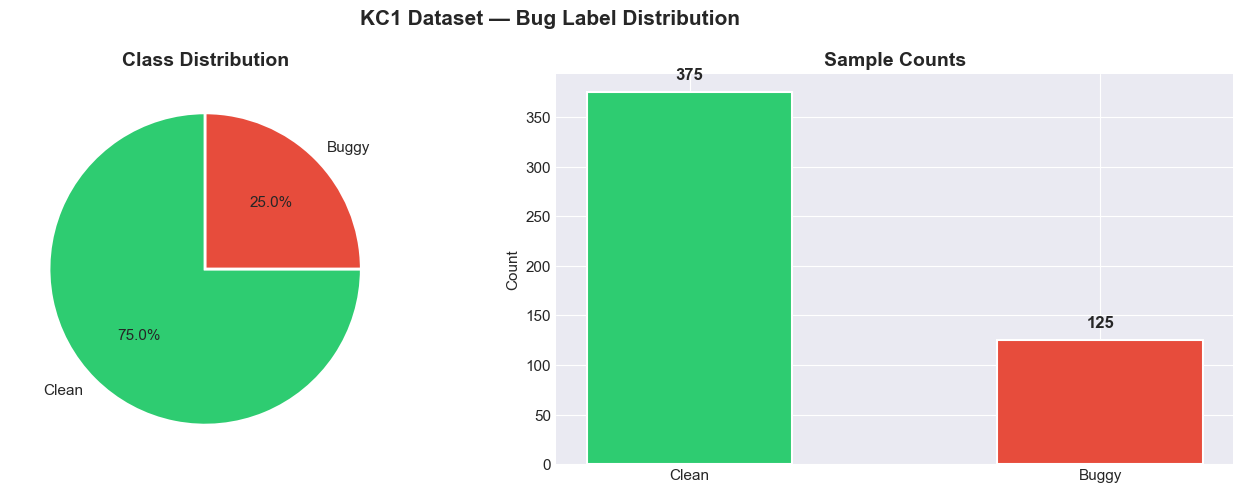

Clean samples:  375
Buggy samples:  125
Bug ratio:      25.0%
Imbalance:      1 buggy : 3.0 clean

Manageable imbalance — class weights still recommended


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sort_index() ensures False (Clean) is first, True (Buggy) is second
bug_counts = df['is_buggy'].value_counts().sort_index()

# Pie chart
axes[0].pie(
    bug_counts.values,
    labels=['Clean', 'Buggy'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(
    ['Clean', 'Buggy'],
    bug_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
axes[1].set_title('Sample Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

# Labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2.,
        height + 10,
        f'{int(height):,}',
        ha='center', va='bottom', fontweight='bold', fontsize=12
    )

plt.suptitle('KC1 Dataset — Bug Label Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

n_clean = bug_counts[False]
n_buggy = bug_counts[True]
print(f'Clean samples:  {n_clean:,}')
print(f'Buggy samples:  {n_buggy:,}')
print(f'Bug ratio:      {df["is_buggy"].mean():.1%}')
print(f'Imbalance:      1 buggy : {n_clean / n_buggy:.1f} clean')
print()
if df['is_buggy'].mean() < 0.15:
    print('HIGH IMBALANCE — will use scale_pos_weight in XGBoost')
else:
    print('Manageable imbalance — class weights still recommended')

## Cell 4 — Feature Distributions: Buggy vs Clean
Good features will show clearly different distributions between the two classes.

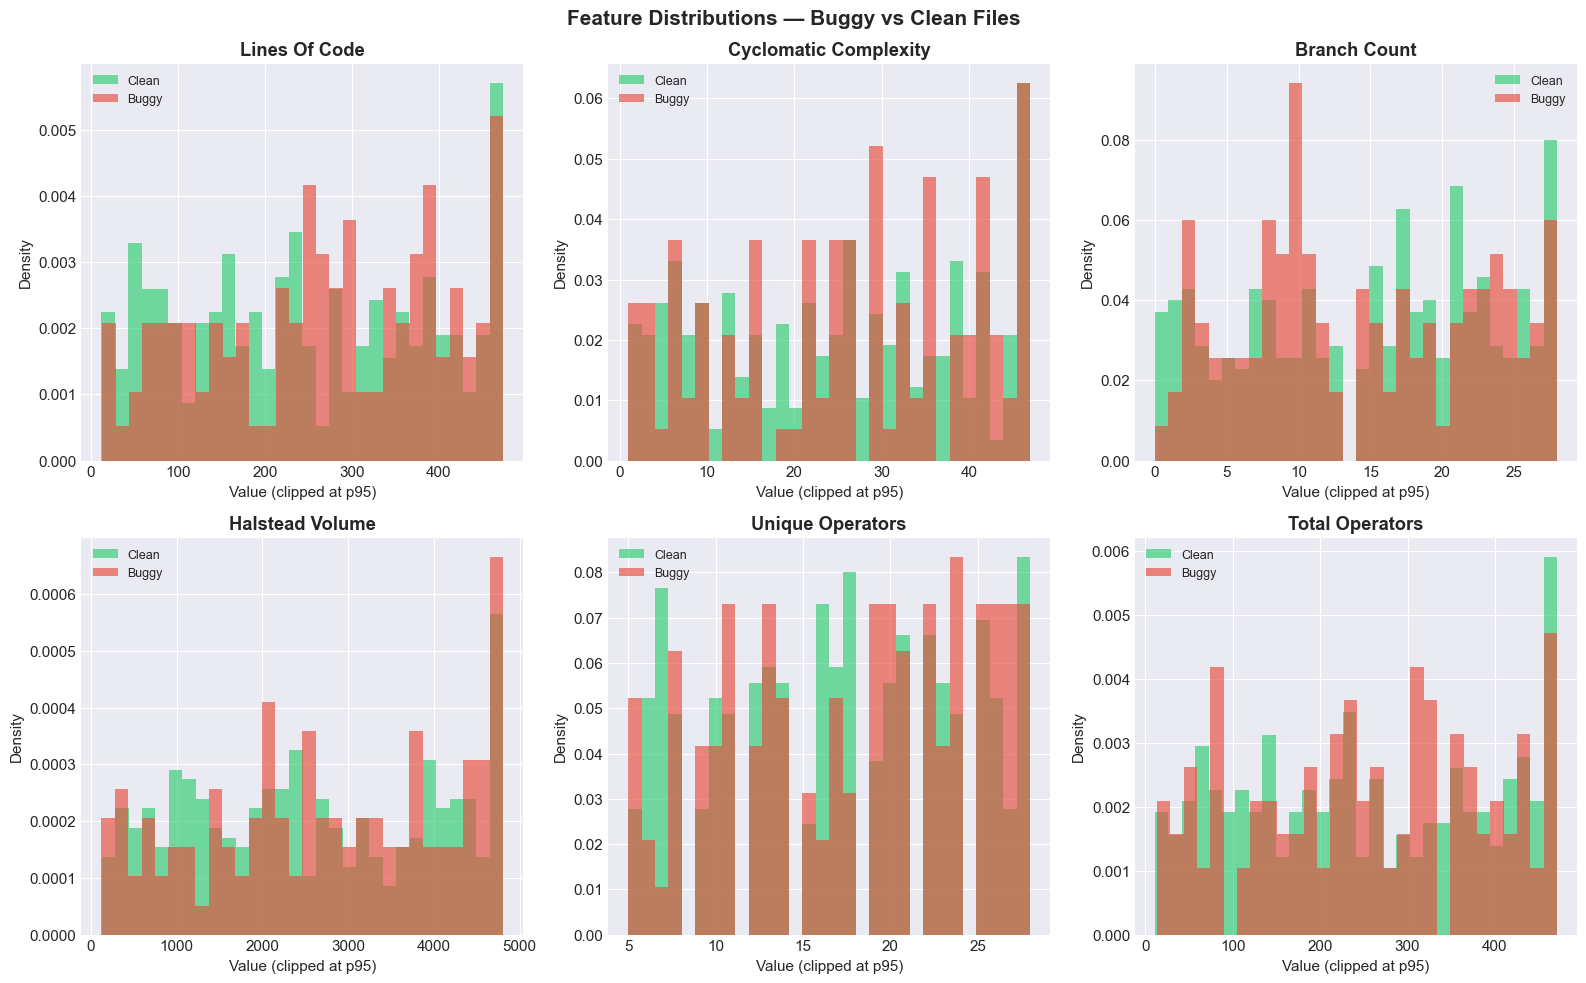

Saved: plots/feature_distributions.png


In [4]:
# Prefer these features if available in the loaded dataset
candidate_features = [
    'lines_of_code', 'cyclomatic_complexity', 'branch_count',
    'halstead_volume', 'unique_operators', 'total_operators',
    'halstead_difficulty', 'halstead_effort', 'lines_of_code_clean'
]
available = [f for f in candidate_features if f in df.columns]

# Fallback: use all numeric features if none of the above match
if len(available) == 0:
    available = [c for c in df.select_dtypes(include='number').columns if c != 'is_buggy']
    print(f'Using all numeric features as fallback: {available}')

plot_features = available[:6]
n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes_flat = np.array(axes).flatten()

for i, feature in enumerate(plot_features):
    ax = axes_flat[i]
    p95 = df[feature].quantile(0.95)
    clean_vals = df[~df['is_buggy']][feature].clip(upper=p95)
    buggy_vals = df[df['is_buggy']][feature].clip(upper=p95)

    ax.hist(clean_vals, alpha=0.65, color='#2ecc71', label='Clean', bins=30, density=True)
    ax.hist(buggy_vals, alpha=0.65, color='#e74c3c', label='Buggy', bins=30, density=True)
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('Value (clipped at p95)')
    ax.set_ylabel('Density')

# Hide any unused subplot slots
for j in range(len(plot_features), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Feature Distributions — Buggy vs Clean Files', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/feature_distributions.png')

## Cell 5 — Feature Correlation with Bug Label
Higher absolute correlation = stronger signal. These will be the most important features.

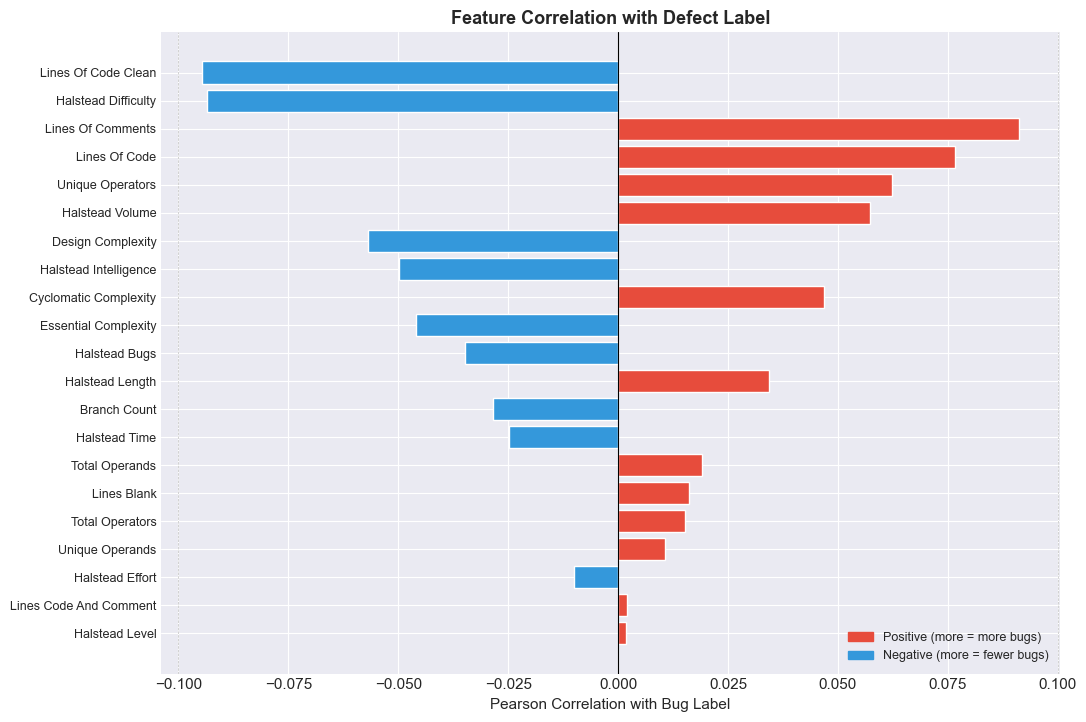

Top 5 risk factors (positive correlation):
  lines_of_comments                   r = +0.0911
  lines_of_code                       r = +0.0765
  unique_operators                    r = +0.0622
  halstead_volume                     r = +0.0572
  cyclomatic_complexity               r = +0.0469

Top 5 protective factors (negative correlation):
  lines_of_code_clean                 r = -0.0946
  halstead_difficulty                 r = -0.0936
  design_complexity                   r = -0.0570
  halstead_intelligence               r = -0.0499
  essential_complexity                r = -0.0459


In [5]:
# Build numeric dataframe — drop target and string metadata columns
exclude_cols = {'is_buggy', 'file_path', 'repo_name', 'dataset_source'}
numeric_df = df.select_dtypes(include='number').drop(
    columns=[c for c in exclude_cols if c in df.columns],
    errors='ignore'
)

# Correlation of each feature with the binary label
target_corr = numeric_df.corrwith(df['is_buggy'].astype(float)).dropna()
target_corr_sorted = target_corr.reindex(
    target_corr.abs().sort_values(ascending=True).index
)

plt.figure(figsize=(11, max(6, len(target_corr_sorted) * 0.35)))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr_sorted.values]
plt.barh(range(len(target_corr_sorted)), target_corr_sorted.values, color=colors, edgecolor='white')
plt.yticks(
    range(len(target_corr_sorted)),
    [t.replace('_', ' ').title() for t in target_corr_sorted.index],
    fontsize=9
)
plt.xlabel('Pearson Correlation with Bug Label', fontsize=11)
plt.title('Feature Correlation with Defect Label', fontsize=13, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.axvline(x=0.1,  color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
plt.axvline(x=-0.1, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

red_patch  = mpatches.Patch(color='#e74c3c', label='Positive (more = more bugs)')
blue_patch = mpatches.Patch(color='#3498db', label='Negative (more = fewer bugs)')
plt.legend(handles=[red_patch, blue_patch], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

top5_pos = target_corr.sort_values(ascending=False).head(5)
top5_neg = target_corr.sort_values(ascending=True).head(5)

print('Top 5 risk factors (positive correlation):')
for feat, corr in top5_pos.items():
    print(f'  {feat:<35} r = {corr:+.4f}')

print('\nTop 5 protective factors (negative correlation):')
for feat, corr in top5_neg.items():
    print(f'  {feat:<35} r = {corr:+.4f}')

## Cell 6 — Correlation Heatmap Between Features
Reveals redundant features we should drop before training.

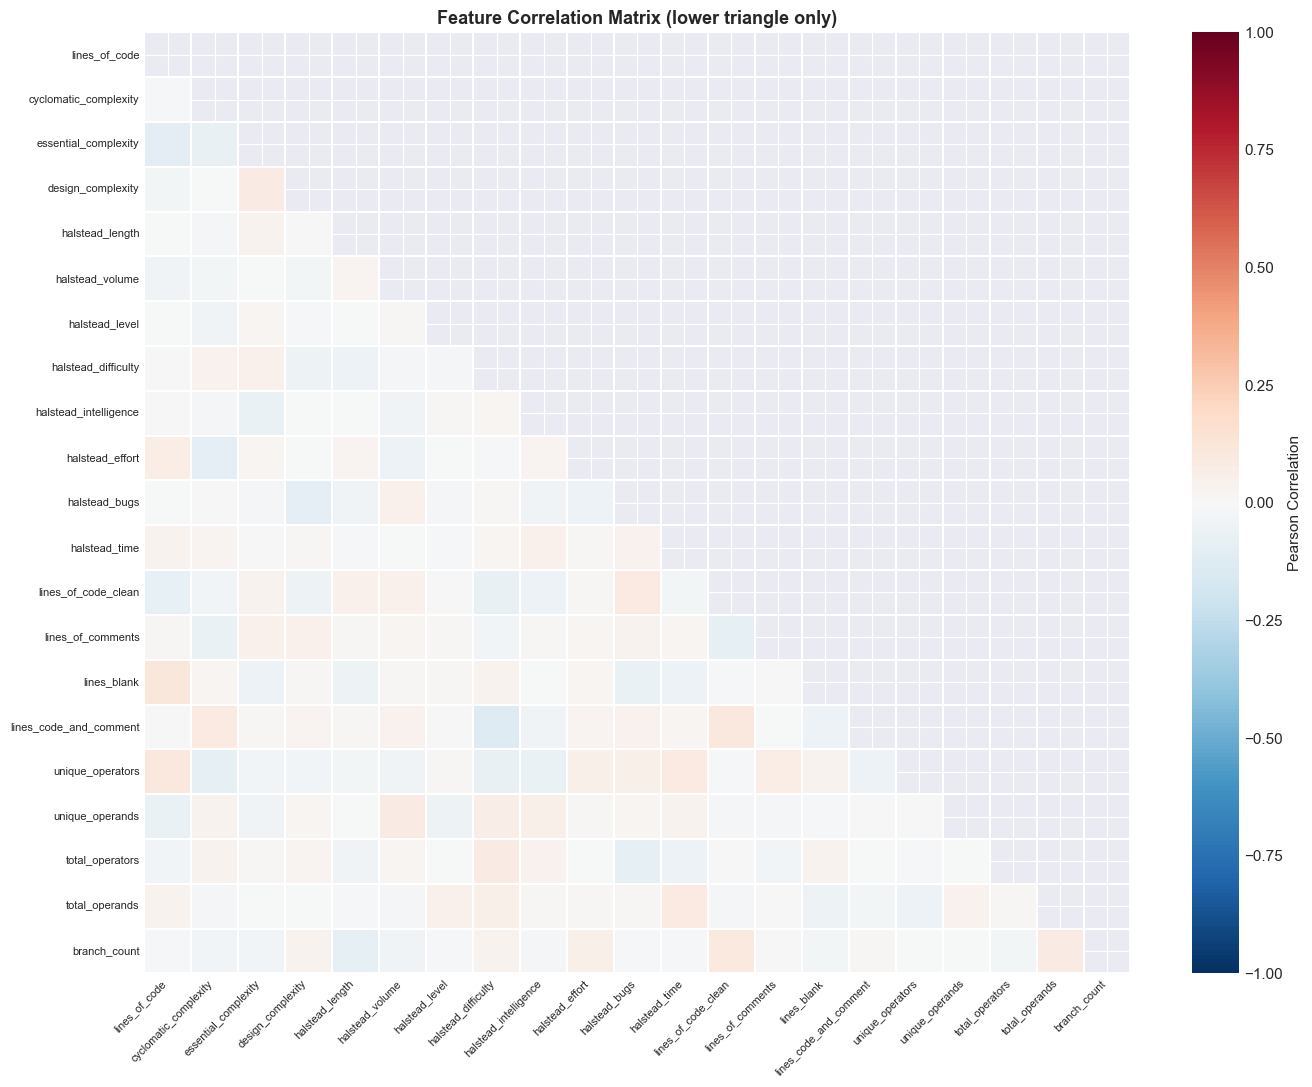

Highly correlated pairs (|r| > 0.95): 0
No redundant feature pairs found


In [6]:
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (redundant)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.3,
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Feature Correlation Matrix (lower triangle only)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Find highly correlated pairs — candidates for dropping
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_pairs = [
    (col, row, round(upper_tri.loc[row, col], 3))
    for col in upper_tri.columns
    for row in upper_tri.index
    if abs(upper_tri.loc[row, col]) > 0.95
]

print(f'Highly correlated pairs (|r| > 0.95): {len(high_corr_pairs)}')
if high_corr_pairs:
    print('Drop one from each pair to reduce redundancy:')
    for col, row, r in high_corr_pairs:
        print(f'  {col} <-> {row}  (r = {r})')
else:
    print('No redundant feature pairs found')

## Cell 7 — Full Data Quality Report

In [7]:
print('=' * 55)
print('          DATA QUALITY REPORT')
print('=' * 55)
print(f'  Total samples:       {len(df):,}')
print(f'  Numeric features:    {len(numeric_df.columns)}')
print(f'  Missing values:      {df.isnull().sum().sum()}')
print(f'  Duplicate rows:      {df.duplicated().sum()}')
print(f'  Bug ratio:           {df["is_buggy"].mean():.1%}')
print()

# Zero variance = completely useless features
zero_var_feats = [c for c in numeric_df.columns if numeric_df[c].std() == 0]
if zero_var_feats:
    print(f'  Zero-variance features (DROP): {zero_var_feats}')
else:
    print('  No zero-variance features')

# Outlier check
print()
print('  Features with heavy outliers (max > 10x mean):')
outlier_feats = []
for col in numeric_df.columns:
    col_mean = numeric_df[col].mean()
    col_max = numeric_df[col].max()
    if col_mean > 0 and col_max / col_mean > 10:
        outlier_feats.append((col, col_max / col_mean))

if outlier_feats:
    for feat, ratio in outlier_feats:
        print(f'    {feat:<30} max/mean = {ratio:.1f}x')
    print('  Consider log-transform for these in Day 2')
else:
    print('  No extreme outliers detected')

print()
print('  Value ranges:')
print(numeric_df.describe().T[['min', 'max', 'mean', 'std']].to_string())

print()
print('=' * 55)
print('  Ready for Day 2 — Feature Engineering')
print('=' * 55)

          DATA QUALITY REPORT
  Total samples:       500
  Numeric features:    21
  Missing values:      0
  Duplicate rows:      0
  Bug ratio:           25.0%

  No zero-variance features

  Features with heavy outliers (max > 10x mean):
  No extreme outliers detected

  Value ranges:
                               min           max          mean           std
lines_of_code            12.000000    499.000000    254.104000    140.116289
cyclomatic_complexity     1.000000     49.000000     25.352000     14.304592
essential_complexity      1.000000     29.000000     15.242000      8.382360
design_complexity         1.000000     19.000000      9.716000      5.558519
halstead_length          21.000000   1998.000000    992.692000    560.788367
halstead_volume         121.098301   4994.265223   2620.570543   1424.281217
halstead_level            0.000568      0.999765      0.488144      0.291145
halstead_difficulty       1.268020     99.769072     51.176155     28.197750
halstead_intellige

## Cell 8 — Mined Git Data Validation
Run AFTER `python scripts/day1_run.py` completes. Skip if mining is still in progress.

Loaded: ..\data\raw\flask_commits.csv
  Total records:   1,107
  Unique commits:  526
  Unique files:    77
  Bug-fix ratio:   22.5%
  Date range:      2018-05-15 to 2026-05-02


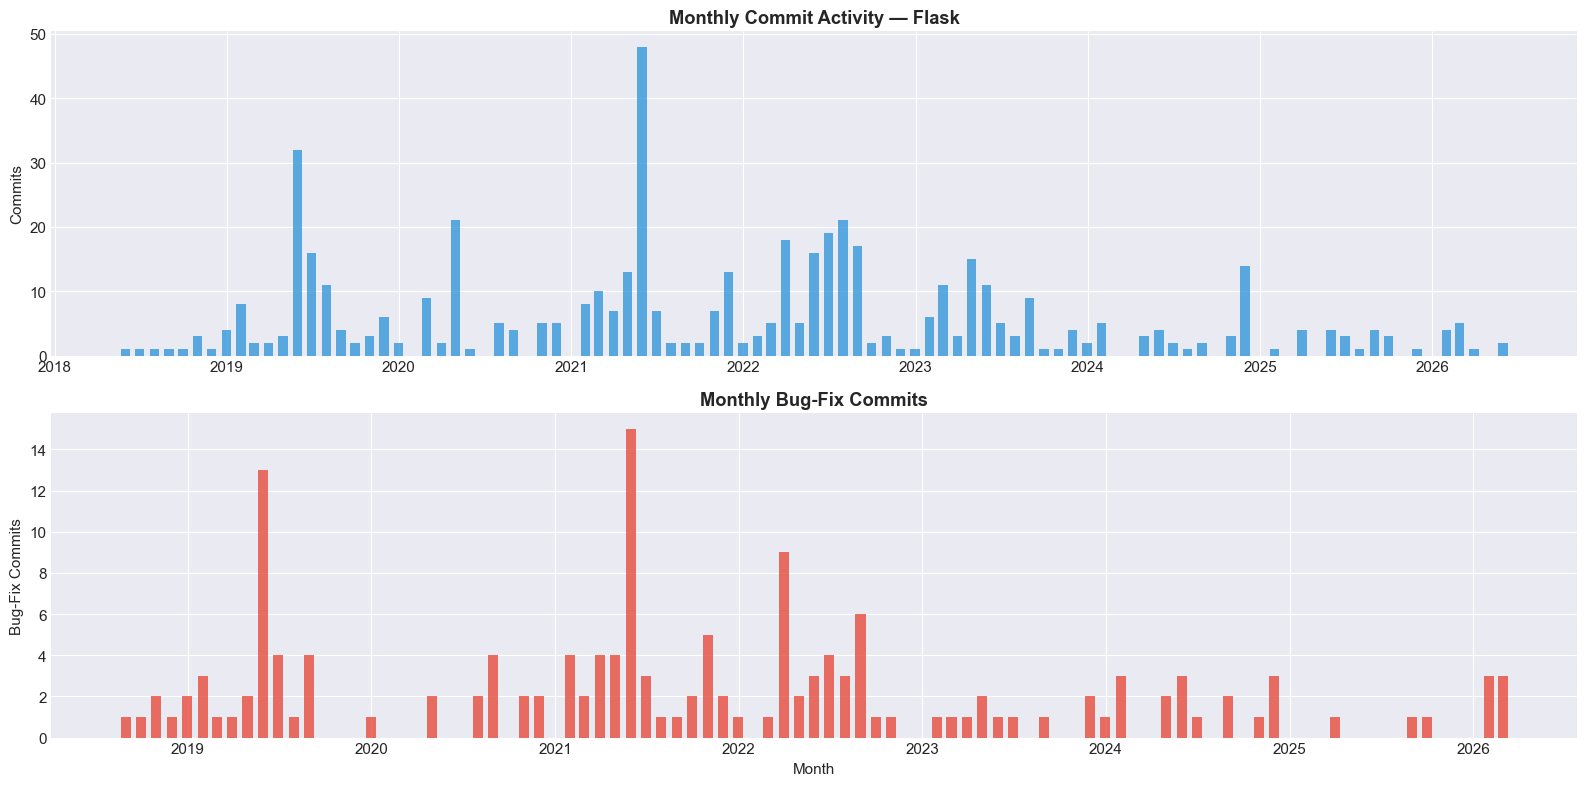


Top 10 highest-churn files (most commit activity):
  134 commits | 42 bug fixes | src/flask/app.py
   88 commits | 22 bug fixes | src/flask/helpers.py
   70 commits |  1 bug fixes | src/flask/__init__.py
   64 commits | 19 bug fixes | src/flask/cli.py
   60 commits | 21 bug fixes | src/flask/blueprints.py
   47 commits | 15 bug fixes | src/flask/scaffold.py
   44 commits | 10 bug fixes | src/flask/ctx.py
   38 commits |  6 bug fixes | src/flask/testing.py
   35 commits |  8 bug fixes | src/flask/sessions.py
   28 commits |  1 bug fixes | setup.py


In [8]:
# Check both possible locations depending on where notebook is opened from
possible_paths = [
    Path('../data/raw/flask_commits.csv'),
    Path('data/raw/flask_commits.csv'),
]
mined_path = next((p for p in possible_paths if p.exists()), None)

if mined_path is None:
    print('No mined data found yet.')
    print('Run this in a terminal: python scripts/day1_run.py')
    print('Come back to this cell once it finishes.')
else:
    df_mined = pd.read_csv(mined_path, parse_dates=['commit_date'])

    print(f'Loaded: {mined_path}')
    print(f'  Total records:   {len(df_mined):,}')
    print(f'  Unique commits:  {df_mined["commit_hash"].nunique():,}')
    print(f'  Unique files:    {df_mined["file_path"].nunique():,}')
    print(f'  Bug-fix ratio:   {df_mined["is_bug_fix"].mean():.1%}')
    print(f'  Date range:      {df_mined["commit_date"].min().date()} to {df_mined["commit_date"].max().date()}')

    # Monthly commit timeline
    monthly_all  = df_mined.set_index('commit_date').resample('ME')['commit_hash'].nunique()
    monthly_bugs = df_mined[df_mined['is_bug_fix']].set_index('commit_date').resample('ME')['commit_hash'].nunique()

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    axes[0].bar(monthly_all.index, monthly_all.values, color='#3498db', alpha=0.8, width=20)
    axes[0].set_title('Monthly Commit Activity — Flask', fontweight='bold')
    axes[0].set_ylabel('Commits')

    axes[1].bar(monthly_bugs.index, monthly_bugs.values, color='#e74c3c', alpha=0.8, width=20)
    axes[1].set_title('Monthly Bug-Fix Commits', fontweight='bold')
    axes[1].set_ylabel('Bug-Fix Commits')
    axes[1].set_xlabel('Month')

    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'commit_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Top churned files — highest risk according to process metrics
    print('\nTop 10 highest-churn files (most commit activity):')
    churn = df_mined.groupby('file_path')['commit_hash'].nunique().sort_values(ascending=False).head(10)
    for filepath, count in churn.items():
        n_bugfix = df_mined[
            (df_mined['file_path'] == filepath) & (df_mined['is_bug_fix'])
        ]['commit_hash'].nunique()
        print(f'  {count:3d} commits | {n_bugfix:2d} bug fixes | {filepath}')

## Cell 9 — End of Day 1 Summary

In [9]:
print('=' * 55)
print('  DAY 1 COMPLETE')
print('=' * 55)

print('\nPlots saved:')
for plot_file in sorted(PLOT_DIR.glob('*.png')):
    size_kb = plot_file.stat().st_size / 1024
    print(f'  {plot_file.name} ({size_kb:.0f} KB)')

print()
print('Key EDA findings:')
print(f'  Bug ratio:            {df["is_buggy"].mean():.1%}')

best_feature = target_corr.abs().sort_values(ascending=False).index[0]
best_corr    = target_corr[best_feature]
print(f'  Strongest predictor:  {best_feature} (r={best_corr:+.3f})')
print(f'  Redundant pairs:      {len(high_corr_pairs)}')
print(f'  Outlier-heavy feats:  {len(outlier_feats)}')

print()
print('Tomorrow — Day 2: Feature Engineering')
print('  - Process metrics: churn, author count, fix density')
print('  - AST structural features: complexity, nesting depth')
print('  - Final feature matrix for XGBoost')

print()
print('Git commit command:')
print('  git add -A')
print('  git commit -m "Day 1: data pipeline, EDA, PROMISE loading"')
print('=' * 55)

  DAY 1 COMPLETE

Plots saved:
  class_distribution.png (65 KB)
  commit_timeline.png (59 KB)
  correlation_heatmap.png (187 KB)
  feature_correlation.png (119 KB)
  feature_distributions.png (157 KB)

Key EDA findings:
  Bug ratio:            25.0%
  Strongest predictor:  lines_of_code_clean (r=-0.095)
  Redundant pairs:      0
  Outlier-heavy feats:  0

Tomorrow — Day 2: Feature Engineering
  - Process metrics: churn, author count, fix density
  - AST structural features: complexity, nesting depth
  - Final feature matrix for XGBoost

Git commit command:
  git add -A
  git commit -m "Day 1: data pipeline, EDA, PROMISE loading"


In [10]:
import pandas as pd

# Load your raw commits data for sqlalchemy
# adjust path to wherever your raw commit CSV is
df = pd.read_csv("d:\\Data Science\\projects\\defect-predictor\\data\\raw\\sqlalchemy_commits.csv")  


    
bug_commits = df[df["is_bug_fix"]]
print(f"Total commits: {len(df)}")
print(f"Bug-fix commits: {len(bug_commits)}")
print()

# How many files does each bug-fix commit touch?
files_per_commit = bug_commits.groupby("commit_hash")["file_path"].count()
print("Files touched per bug-fix commit:")
print(files_per_commit.describe())
print()
print("Top 10 largest bug-fix commits:")
print(files_per_commit.sort_values(ascending=False).head(10))

Total commits: 12487
Bug-fix commits: 7813

Files touched per bug-fix commit:
count    2119.000000
mean        3.687117
std        10.199881
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       240.000000
Name: file_path, dtype: float64

Top 10 largest bug-fix commits:
commit_hash
1e1a38e7801f410f244e4bbb44ec795ae152e04e    240
1e278de4cc9a4181e0747640a960e80efcea1ca9    228
f2bd4f513628bb2a7a8e8b36383e3a4324eac803    126
1e1c0084b1804eaae8b7f089435241a2b8f4be60    121
e545298e35ea9f126054b337e4b5ba01988b29f7    107
4eb4ceca36c7ce931ea65ac06d6ed08bf459fc66     87
d69765829c9fbc98f21a22dbc496f2b7b22dc52c     71
c3f102c9fe9811fd5286628cc6aafa5fbc324621     66
c3acf8a5d23881ed4795fb5ca1c28fae0adc6414     63
bb3c24595d503a1daf764e18efd8b85986808463     61
Name: file_path, dtype: int64
